In [46]:

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score

from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression



In [47]:
# Load dataset
df = pd.read_csv(r"E:\Internship_project\Dataset\Air-quality-Classification\City_Types.csv")



In [48]:
print(df.head())

                        Date    City     CO   NO2   SO2    O3  PM2.5  PM10  \
0  2024-01-01 00:00:00+00:00  Moscow  208.0  15.9  13.2  44.0    8.6   9.4   
1  2024-01-01 01:00:00+00:00  Moscow  207.0  17.4  13.7  44.0    8.6  10.5   
2  2024-01-01 02:00:00+00:00  Moscow  217.0  19.0  15.5  43.0   10.4  12.9   
3  2024-01-01 03:00:00+00:00  Moscow  231.0  21.0  20.7  36.0   12.3  15.3   
4  2024-01-01 04:00:00+00:00  Moscow  263.0  34.5  27.2  27.0   13.6  20.0   

         Type  
0  Industrial  
1  Industrial  
2  Industrial  
3  Industrial  
4  Industrial  


In [49]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52704 entries, 0 to 52703
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    52704 non-null  object 
 1   City    52704 non-null  object 
 2   CO      52704 non-null  float64
 3   NO2     52704 non-null  float64
 4   SO2     52704 non-null  float64
 5   O3      52704 non-null  float64
 6   PM2.5   52704 non-null  float64
 7   PM10    52704 non-null  float64
 8   Type    52704 non-null  object 
dtypes: float64(6), object(3)
memory usage: 3.6+ MB
None


In [50]:
import seaborn as sns

In [51]:
df = df.drop('Date', axis=1)



In [52]:
# Encode categorical columns
le = LabelEncoder()
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])



In [53]:
# 🔴 CHANGE TARGET COLUMN NAME HERE
target_column = "Type"

X = df.drop(target_column, axis=1)
y = df[target_column]



<Figure size 640x480 with 0 Axes>

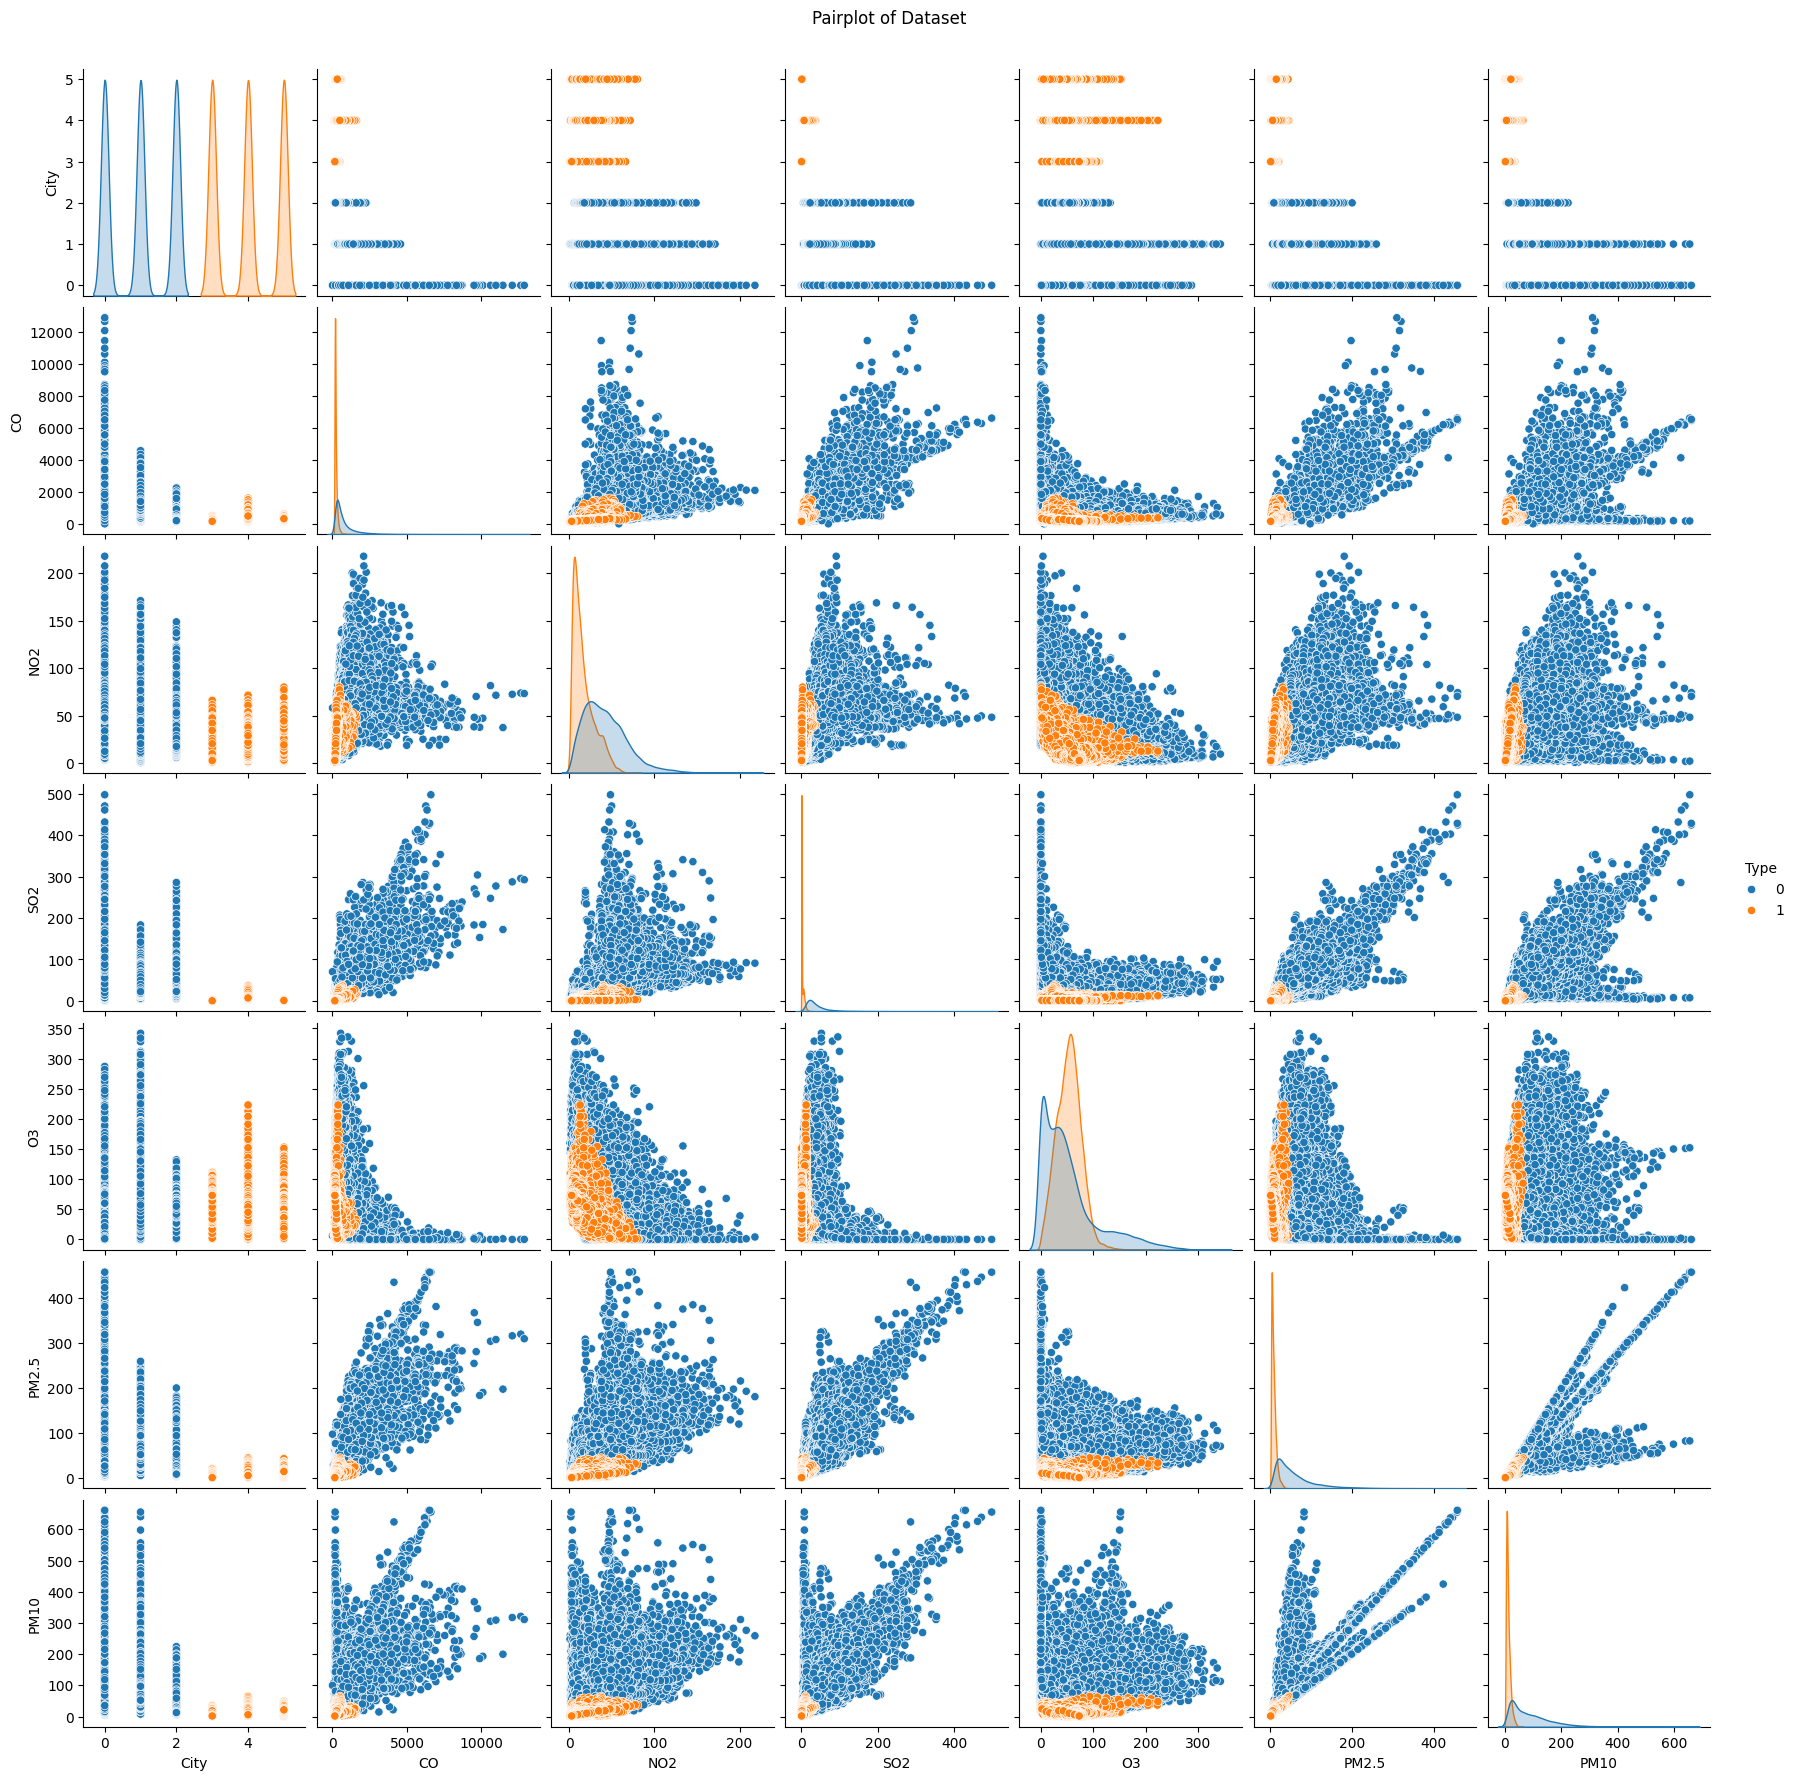

In [54]:
# Pairplot
plt.figure()
sns.pairplot(df, hue=target_column)
plt.suptitle("Pairplot of Dataset", y=1.02)
plt.show()

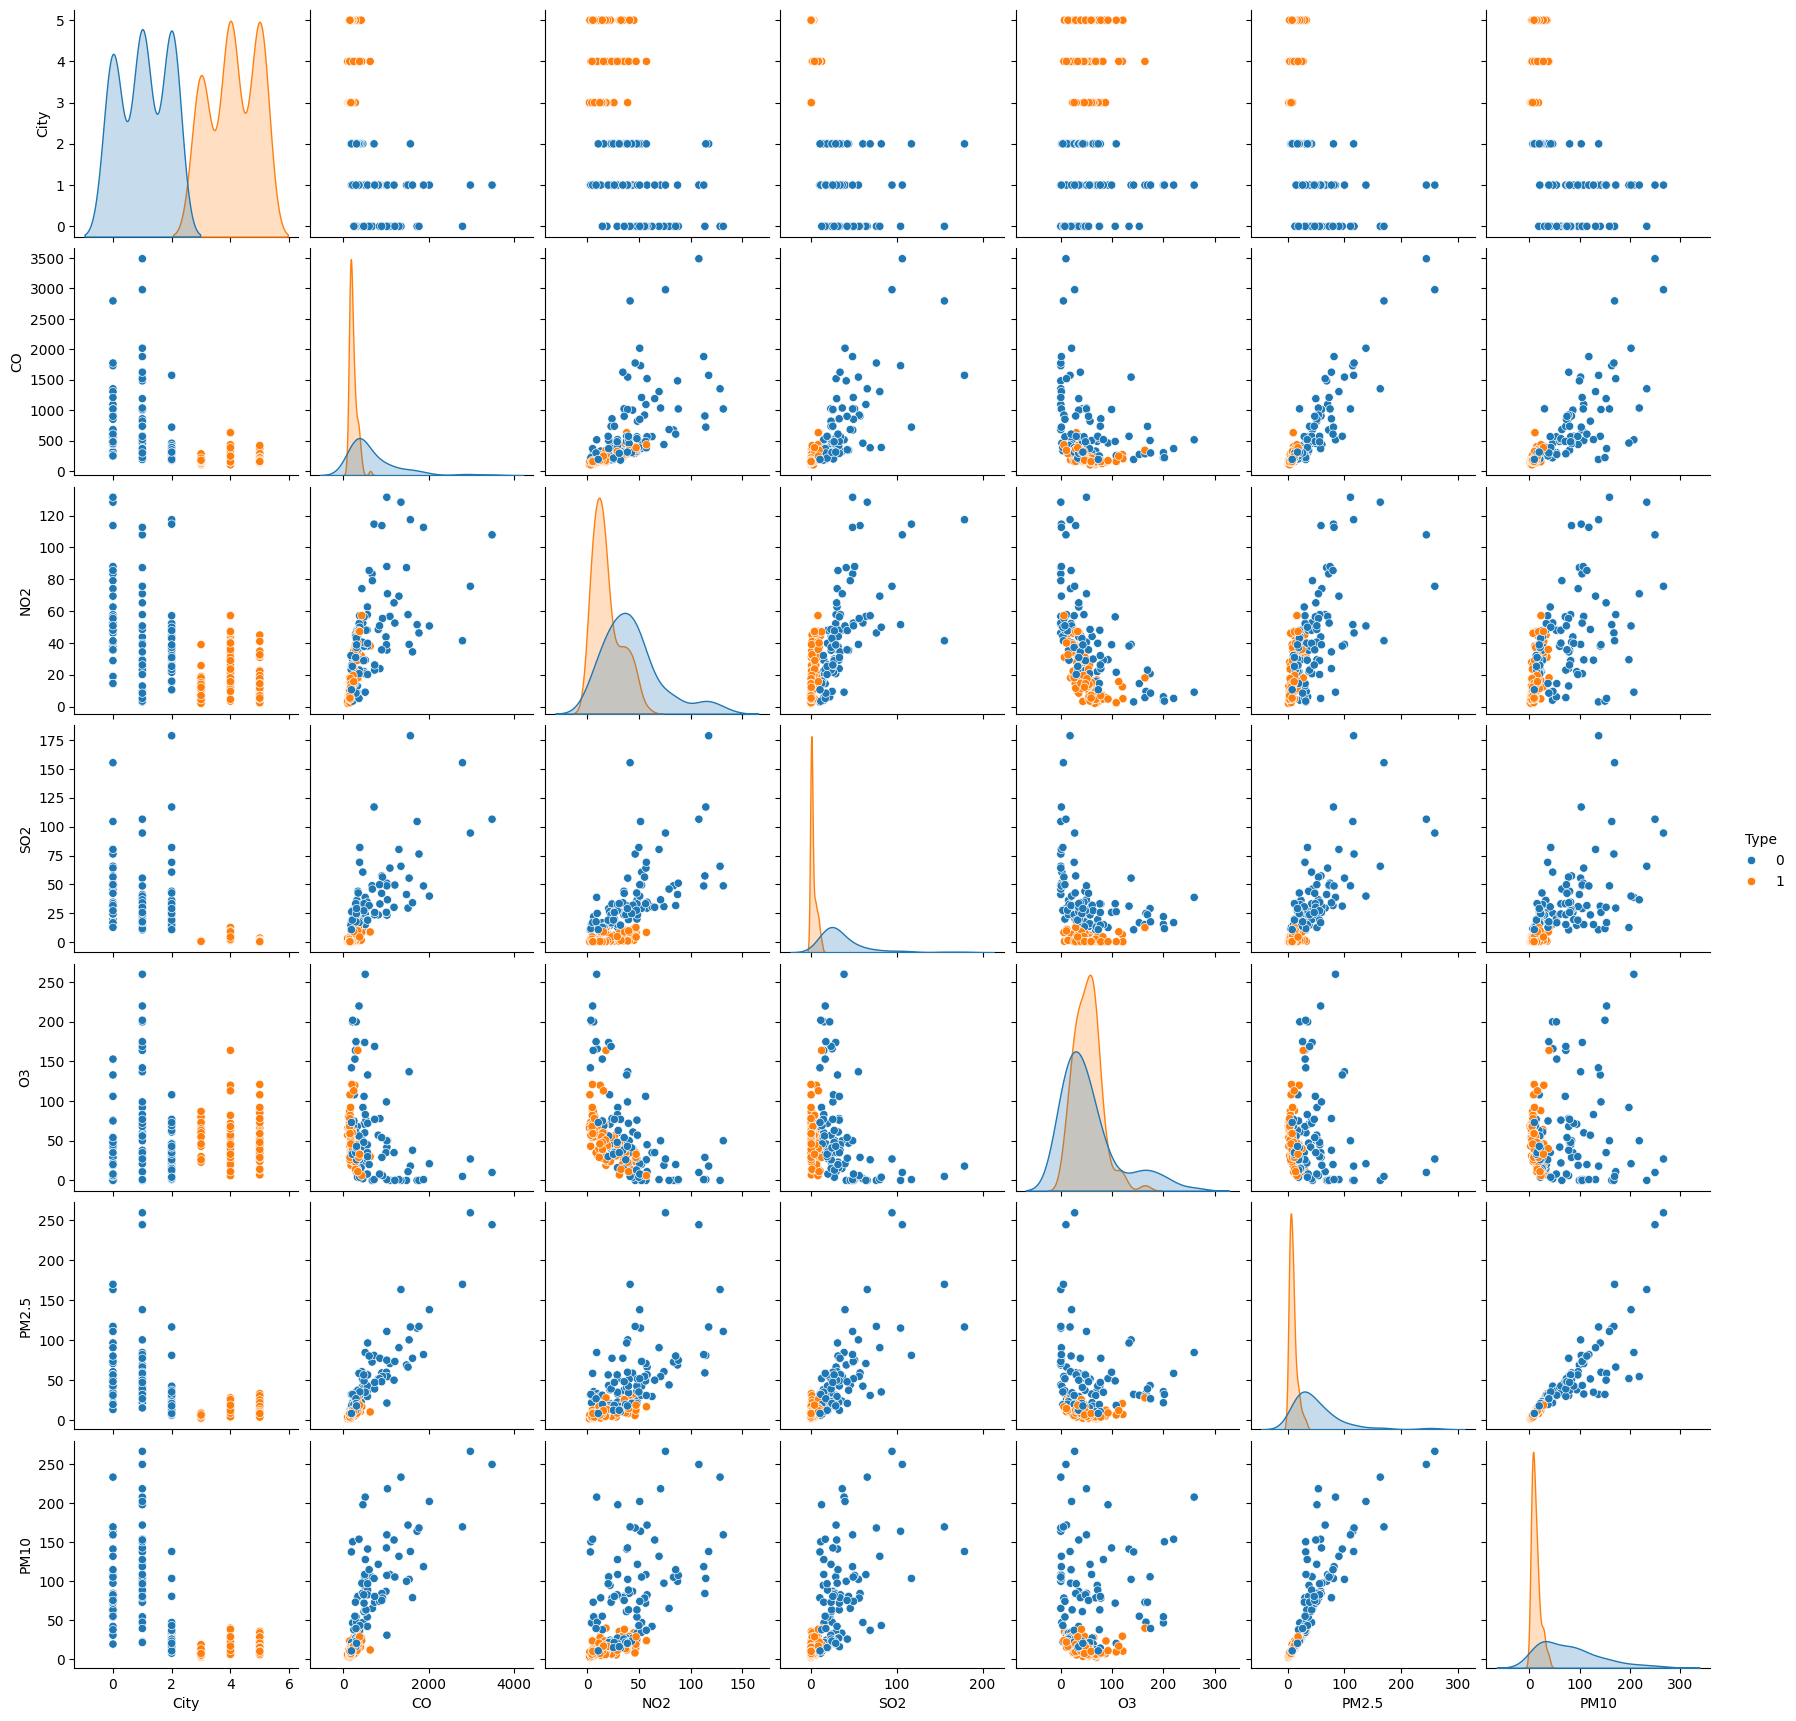

In [55]:
sns.pairplot(df.sample(200), hue=target_column)

In [56]:
# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)



In [57]:
# Models
models = {
    "KNN": KNeighborsClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "Logistic Regression": LogisticRegression(max_iter=1000)
}

accuracies = {}



In [58]:
# Train & Evaluate
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    accuracies[name] = acc
    print(f"{name} Accuracy: {acc:.4f}")



KNN Accuracy: 1.0000
Random Forest Accuracy: 1.0000
Decision Tree Accuracy: 1.0000
Logistic Regression Accuracy: 1.0000


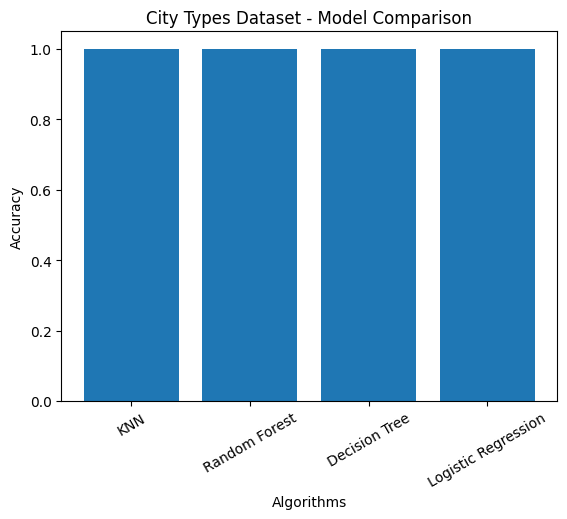

In [59]:
# Plot
plt.figure()
plt.bar(accuracies.keys(), accuracies.values())
plt.xlabel("Algorithms")
plt.ylabel("Accuracy")
plt.title("City Types Dataset - Model Comparison")
plt.xticks(rotation=30)
plt.show()

In [60]:
import joblib
import os

# Create directory 'city' if it doesn't exist
os.makedirs("city", exist_ok=True)

In [61]:
# Save models
for name, model in models.items():
    filename = f"city/{name.replace(' ', '_')}.pkl"
    joblib.dump(model, filename)
    print(f"{name} saved to {filename}")

KNN saved to city/KNN.pkl
Random Forest saved to city/Random_Forest.pkl
Decision Tree saved to city/Decision_Tree.pkl
Logistic Regression saved to city/Logistic_Regression.pkl


In [62]:
joblib.dump(scaler, "city/scaler.pkl")
print("Scaler saved")

Scaler saved


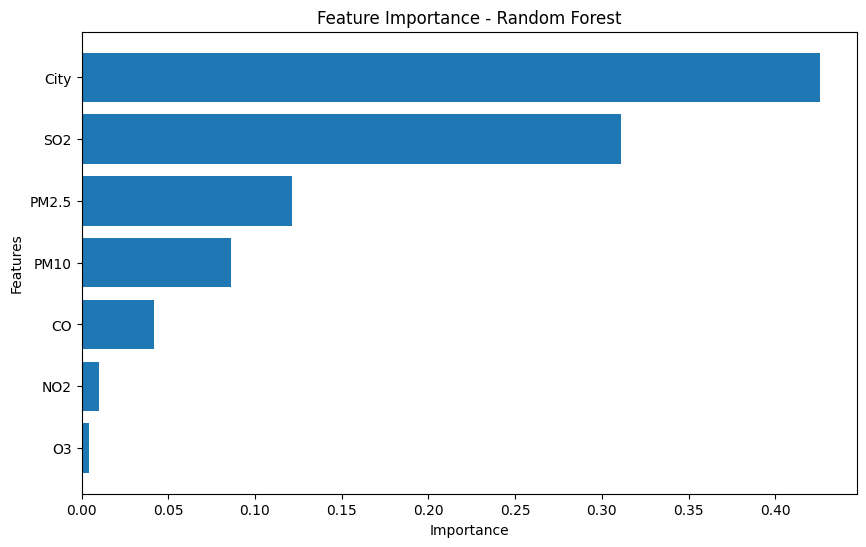

In [63]:
# Feature Importance - Random Forest
rf_model = models["Random Forest"]

importances = rf_model.feature_importances_
features = X.columns

# Create DataFrame for better visualization
feat_df = pd.DataFrame({
    "Feature": features,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

# Plot
plt.figure(figsize=(10, 6))
plt.barh(feat_df["Feature"], feat_df["Importance"])
plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("Feature Importance - Random Forest")
plt.gca().invert_yaxis()  # highest on top
plt.show()

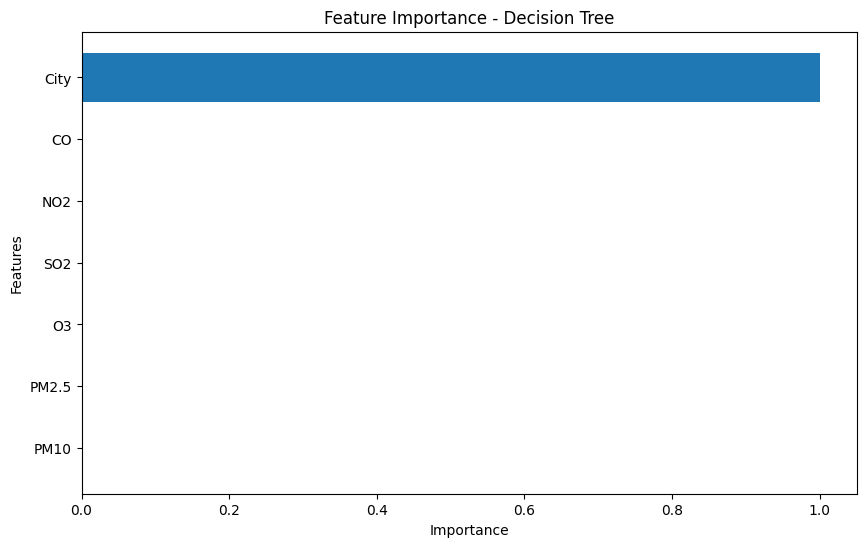

In [64]:
# Feature Importance - Decision Tree
dt_model = models["Decision Tree"]

importances = dt_model.feature_importances_

feat_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(feat_df["Feature"], feat_df["Importance"])
plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("Feature Importance - Decision Tree")
plt.gca().invert_yaxis()
plt.show()

In [65]:
# Print all accuracies
print("\n=== Model Accuracies ===")
for name, acc in accuracies.items():
    print(f"{name}: {acc:.4f}")

# Find best algorithm
best_model = max(accuracies, key=accuracies.get)
best_accuracy = accuracies[best_model]

print("\n=== Best Model ===")
print(f"Best Algorithm: {best_model}")
print(f"Accuracy: {best_accuracy:.4f}")


=== Model Accuracies ===
KNN: 1.0000
Random Forest: 1.0000
Decision Tree: 1.0000
Logistic Regression: 1.0000

=== Best Model ===
Best Algorithm: KNN
Accuracy: 1.0000


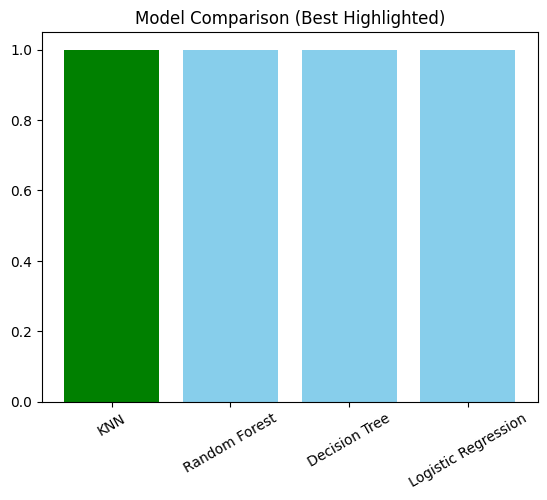

In [66]:
colors = ['green' if name == best_model else 'skyblue' for name in accuracies.keys()]

plt.figure()
plt.bar(accuracies.keys(), accuracies.values(), color=colors)
plt.title("Model Comparison (Best Highlighted)")
plt.xticks(rotation=30)
plt.show()

In [67]:
print("\n====================================")
print("✅ All algorithms trained successfully")
print("✅ Models saved in 'city' directory")
print("🚀 Project execution completed!")
print("====================================")


✅ All algorithms trained successfully
✅ Models saved in 'city' directory
🚀 Project execution completed!
